# Reinforcement Learning for Monetary Policy

## Overview

This notebook uses reinforcement learning to train an agent to act as the central bank of the US. Each month, the agent chooses an interest-rate change (%) to keep the economy close to key macroeconomic targets (inflation, unemployment, and GDP growth).

The agent learns by interacting with a **stochastic** macroeconomic simulator and maximizing a reward that penalizes deviations from macroeconomic targets (and overly abrupt interest rate changes). The simulator includes shocks and rare recession events to encourage **robust (resilient)** policies, and we highlight **COVID (2020)** as a stress period.

## Testing & Evaluation

- **Simulation evaluation**: Compared PPO/DDPG against a **Random** baseline and an **augmented Taylor Rule** over multiple stochastic episodes using total reward.
- **Comparison with Real-data**: Ran the model on the actual deterministic macroeconomic environment and compared interest rate values that were outputted by the models in relation to the actual interest rate values. 

## How to run

- Training cells have been commented out. 
- Trained models located in `models/` folder, the notebook loads them. 
- To retrain, uncomment the PPO/DDPG training cells and rerun.

## 1. Setup

Install and importing all required libraries.

In [1]:
# Installing dependencies if needed
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "gymnasium", "stable-baselines3", "torch", "pandas", "numpy"], check=True)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['/usr/local/bin/python3', '-m', 'pip', 'install', 'gymnasium', 'stable-baselines3', 'torch', 'pandas', 'numpy'], returncode=0)

In [2]:
import os
import collections
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

print("All imports OK")

All imports OK


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---

## 2. Data

We compiled our dataset of US macroeconomic indicators covering **96 monthly observations from January 2017 to December 2024** (Federal Reserve Bank of St. Louis, 2025). The raw file (`us_macro_data_real.csv`) contains five columns which are renamed on load to a consistent internal schema:

| Raw Column | Internal Name | Description |
|---|---|---|
| `GDP Growth` | `gdp_growth` | Monthly GDP growth % |
| `Inflation` | `inflation` | CPI year-on-year % |
| `Unemployment Rate` | `unemployment` | Unemployment rate % |
| `Interest rate` | `interest_rate` | Federal Funds Rate % |

This period was deliberately chosen because it captures some economic shocks: primarily the COVID shock of 2020, and the supply-driven inflation surge of 2021–2022, and the aggressive tightening cycle through 2023–2024. This gives the simulator a wide range of realistic starting conditions to sample from.

In the training phase, the data is used **only to seed episode starting states**. Once seeded, the simulator runs entirely on its own AR1 dynamics — generating trajectories that include counterfactual scenarios that never historically occurred. This is essential: the agent must learn a policy that generalises beyond the specific path the real economy took.

In [3]:
DATA_PATH = "data/us_macro_data_real.csv"

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns={
        "GDP Growth":         "gdp_growth",
        "Inflation":          "inflation",
        "Unemployment Rate ": "unemployment",
        "Unemployment Rate":  "unemployment",
        "Interest rate":      "interest_rate",
    })
    required = {"inflation", "unemployment", "gdp_growth", "interest_rate"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    df = df[["inflation", "unemployment", "gdp_growth", "interest_rate"]].dropna()
    print(f"Loaded {len(df)} timesteps from '{path}'")
    return df

df = load_data(DATA_PATH)
df.describe().round(2)

Loaded 96 timesteps from 'data/us_macro_data_real.csv'


,inflation,unemployment,gdp_growth,interest_rate
count,96.00,96.00,96.00,96.00
mean,3.97,4.58,0.20,2.16
std,1.01,1.92,0.69,1.91
min,1.84,3.31,-2.77,0.05
25%,3.28,3.66,0.17,0.30
50%,4.03,3.92,0.24,1.68
75%,4.68,4.50,0.31,4.16
max,6.05,14.44,2.59,5.33


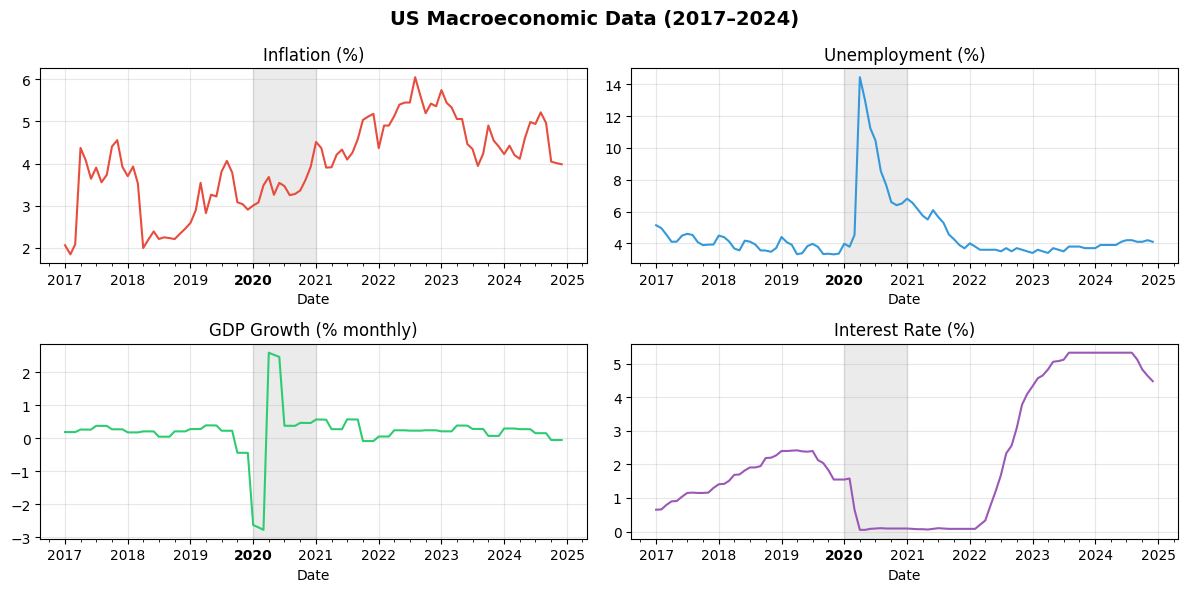

In [4]:
import matplotlib.dates as mdates

# Use the real month column for the x-axis
# (the CSV has a 'Month' column like '2017-01')
if "Month" in df.columns:
    dates = pd.to_datetime(df["Month"], format="%Y-%m")
else:
    # fallback: assume the data starts in 2017-01 and is monthly
    dates = pd.date_range("2017-01-01", periods=len(df), freq="MS")

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle("US Macroeconomic Data (2017–2024)", fontsize=14, fontweight="bold")

titles  = ["Inflation (%)", "Unemployment (%)", "GDP Growth (% monthly)", "Interest Rate (%)"]
columns = ["inflation", "unemployment", "gdp_growth", "interest_rate"]
colors  = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]

for ax, col, title, color in zip(axes.flat, columns, titles, colors):
    ax.plot(dates, df[col].values, color=color, linewidth=1.5)

    # Highlight 2020 crisis window
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"), color="black", alpha=0.08)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)

    # Year ticks (major), with quarterly minor ticks
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))

# Make the '2020' tick label bold (requires draw first)
fig.canvas.draw()
for ax in axes.flat:
    for lbl in ax.get_xticklabels():
        if lbl.get_text() == "2020":
            lbl.set_fontweight("bold")

plt.tight_layout()
plt.show()

By taking a look at our data for the US above, we can see all actual values for macroeconomic indicators as well as the actual values for interest rate set by the central bank during the period selected.

The period of 2020 has been shaded in grey to notice the changes in these macroeconomic indicators due to the COVID-19 pandemic. It can clearly be seen that in early 2020, the unemployment rate rose steeply. In contrast, interest rate decreased steeply. This immediately indicates an inverse relationship between unemployment rate and interest rate. Additionally, the GDP growth rate shows a negative growth rate at the very beginning of 2020, with a steep increase from mid 2020 onwards. 

---

## 3. The Macroeconomic Stochastic Environment

### 3.1 What is the Environment?

The environment is a **macro-economic simulator** built as a standard Gymnasium MDP (Markov Decision Process). At each step:

- The agent **observes** the current state of the economy
- The agent **acts** by raising or lowering the interest rate
- The environment **transitions** to a new state using economic equations
- The agent **receives a reward** based on how close the economy is to its targets

This is framed as a game: the agent plays the role of the Federal Reserve and tries to maximise cumulative reward over a simulated episode of 95 months.

---

### 3.2 State Space (6 Dimensions)

The agent observes a 6-dimensional vector each step:

| Index | Variable | Bounds | Description |
|---|---|---|---|
| 0 | `inflation` | [-10, 30] | CPI year-on-year % |
| 1 | `unemployment` | [0, 30] | Unemployment rate % |
| 2 | `gdp_growth` | [-20, 20] | Monthly GDP growth % |
| 3 | `interest_rate` | [-2, 25] | Current Fed Funds rate % |
| 4 | `action_{t-1}` | [-1, 1] | Rate change last step |
| 5 | `action_{t-2}` | [-1, 1] | Rate change two steps ago |

The last two slots — the **action history** — are important. Because monetary policy transmission is delayed (a rate hike today doesn't fully affect inflation for 1–2 months), the agent needs to see what it already did. Without this, the agent could keep hiking into a lag it already set in motion, causing overshooting.

---

### 3.3 Action Space

The agent has a single continuous action:

$$a_t \in [-1,\ +1] \quad \text{(percentage point change in interest rate)}$$

The new rate is: $r_{t+1} = \text{clip}(r_t + a_t,\ -0.5,\ 20.0)$

A +1 action means a full 100 basis point hike; a -1 means a full 100bp cut.

---

### 3.4 Reward Function

The reward at each step is a **quadratic loss** — it is always negative and reaches zero only when all targets are met simultaneously:

$$R_t = -\Big(1.0\,(\pi_t - 2)^2 + 0.5\,(u_t - 4.5)^2 + 0.5\,(g_t - 0.25)^2 + 0.1\,(\Delta r_t)^2\Big)$$

| Term | Weight | Target | Rationale |
|---|---|---|---|
| Inflation | 1.0 | 2.0% | Primary central bank mandate |
| Unemployment | 0.5 | 4.5% | NAIRU / Fed dual mandate |
| GDP growth | 0.5 | 0.25%/month | ~3% annualised stable growth |
| Rate smoothing | 0.1 | Δr = 0 | Penalise abrupt policy shifts |

Inflation receives the highest weight because price stability is the primary mandate of a central bank.

---

### 3.5 Transition Dynamics

The simulator uses empirically-calibrated **AR1 (autoregressive) equations** — each variable mean-reverts toward a steady state while being pushed by policy actions and random shocks.

**GDP** (IS curve with level drag):
$$g_{t+1} = \rho_g\, g_t + (1-\rho_g)\, G_{SS} - f_g(\text{actions}) - \underbrace{\phi(r_t - 2.5)}_{\text{IS drag}} + \varepsilon_g$$

The IS drag term means GDP is continuously suppressed **while** rates stay above the neutral rate (2.5%), not just when they are raised. This forces the agent to learn to cut back to neutral once inflation is tamed — it cannot simply hold rates high forever.

**Inflation** (Phillips curve):
$$\pi_{t+1} = \rho_\pi\, \pi_t + (1-\rho_\pi)\, \pi_{SS} - f_\pi(\text{actions}) + \underbrace{\kappa(g_t - G_{SS})}_{\text{output gap}} + \varepsilon_\pi$$

Hot growth above trend ($g_t > 0.25\%$) pushes inflation up next period via the Phillips curve ($\kappa = 0.12$).

**Unemployment** (Okun's Law):
$$u_{t+1} = \rho_u\, u_t + (1-\rho_u)\, U_{SS} - \delta(g_{t+1} - G_{SS}) + \varepsilon_u$$

Below-trend GDP growth raises unemployment — a standard empirical regularity.

**Policy transmission** is lagged and nonlinear: a rate change today affects inflation mostly at lags 1–2, while GDP feels it immediately. A signed quadratic add-on captures the financial accelerator (large hikes cause disproportionate credit tightening).

**Stochasticity**: inflation and GDP shocks are **correlated** ($\rho = -0.5$) to capture supply shocks (cost-push raises inflation and lowers growth simultaneously). A 1.5%/month recession probability injects occasional GDP contractions and unemployment spikes.

| Constant | Value | Source |
|---|---|---|
| $\rho_\pi$ | 0.75 | Fuhrer (2010) |
| $\rho_u$ | 0.92 | Shimer (2005) |
| $\rho_g$ | 0.40 | Stock & Watson (1999) |
| Neutral rate | 2.5% | Laubach-Williams (2024) |
| IS coefficient $\phi$ | 0.25 | Smets & Wouters (2007) |
| Phillips slope $\kappa$ | 0.12 | Galí & Gertler (1999) |
| Okun coefficient $\delta$ | 0.15 | Okun (1962) |

### 3.6 Environment Code

In [5]:
class EconomicEnv(gym.Env):
    """
    Single-country monetary policy environment.

    State  : [inflation, unemployment, gdp_growth, interest_rate, a_{t-1}, a_{t-2}]
    Action : continuous rate change in [-1, +1] (percentage points per month)
    Reward : quadratic loss on deviations from macro targets
    """

    metadata = {"render_modes": []}

    # --- Macro targets ---------------------------------------------------
    INFLATION_TARGET    = 2.0
    UNEMPLOYMENT_TARGET = 4.5
    GDP_TARGET          = 0.25
    RATE_MIN            = -0.5
    RATE_MAX            = 20.0

    # --- AR1 persistence coefficients ------------------------------------
    RHO_PI = 0.75   # Fuhrer (2010)
    RHO_U  = 0.92   # Shimer (2005)
    RHO_G  = 0.40   # Stock & Watson (1999)

    # --- Steady states (long-run attractors) -----------------------------
    PI_SS = 2.5
    U_SS  = 4.5
    G_SS  = 0.25

    # --- Lagged policy transmission weights ------------------------------
    # Inflation: slow — peaks at lag 1 (sticky prices)
    # GDP:       fast — front-loaded at lag 0 (immediate credit channel)
    W_PI = np.array([0.10, 0.20, 0.15])
    W_G  = np.array([0.25, 0.10, 0.05])

    # --- IS curve --------------------------------------------------------
    NEUTRAL_RATE = 2.5   # Laubach-Williams (2024)
    IS_COEFF     = 0.25  # Smets & Wouters (2007)

    # --- Phillips curve --------------------------------------------------
    KAPPA = 0.12         # Galí & Gertler (1999)

    # --- Okun's law ------------------------------------------------------
    OKUN = 0.15

    # --- Nonlinear policy effects (financial accelerator) ----------------
    NL_PI = 0.08
    NL_G  = 0.08

    # --- Shock structure -------------------------------------------------
    SHOCK_STD_PI = 0.12
    SHOCK_STD_G  = 0.22
    SHOCK_STD_U  = 0.07
    SUPPLY_CORR  = -0.50  # Blanchard & Galí (2007)
    P_RECESSION  = 0.015  # ~1 recession per 5.5 years

    # --- Hard bounds (RL stability) --------------------------------------
    PI_MIN, PI_MAX = -5.0, 25.0
    U_MIN,  U_MAX  =  0.0, 20.0
    G_MIN,  G_MAX  = -5.0,  8.0

    def __init__(self, data: pd.DataFrame):
        super().__init__()
        self.data    = data.reset_index(drop=True)
        self.n_steps = len(self.data)

        # 6D observation space
        self.observation_space = spaces.Box(
            low=np.array( [-10.0,  0.0, -20.0, -2.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([ 30.0, 30.0,  20.0, 25.0,  1.0,  1.0], dtype=np.float32),
            dtype=np.float32,
        )

        # 1D continuous action space
        self.action_space = spaces.Box(
            low=np.array( [-1.0], dtype=np.float32),
            high=np.array([ 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self._sim_state      = {}
        self.current_step    = 0
        self._action_history = collections.deque([0.0, 0.0, 0.0], maxlen=3)

        # Precompute shock covariance matrix
        self._shock_cov = np.array([
            [self.SHOCK_STD_PI ** 2,
             self.SUPPLY_CORR * self.SHOCK_STD_PI * self.SHOCK_STD_G],
            [self.SUPPLY_CORR * self.SHOCK_STD_PI * self.SHOCK_STD_G,
             self.SHOCK_STD_G ** 2],
        ])

    def _get_obs(self) -> np.ndarray:
        s = self._sim_state
        return np.array(
            [s["inflation"], s["unemployment"], s["gdp_growth"], s["interest_rate"],
             self._action_history[0], self._action_history[1]],
            dtype=np.float32,
        )

    def _compute_reward(self, inflation, unemployment, gdp_growth,
                        current_rate, previous_rate) -> float:
        return float(
            -(
                1.0 * (inflation    - self.INFLATION_TARGET)    ** 2
              + 0.5 * (unemployment - self.UNEMPLOYMENT_TARGET) ** 2
              + 0.5 * (gdp_growth   - self.GDP_TARGET)          ** 2
              + 0.1 * (current_rate  - previous_rate)            ** 2
            )
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0

        # Sample starting state from first 80% of dataset
        max_start = max(1, int(0.8 * self.n_steps))
        start_idx = int(self.np_random.integers(0, max_start))
        row = self.data.iloc[start_idx]

        self._sim_state = {
            "inflation":     float(row["inflation"]),
            "unemployment":  float(row["unemployment"]),
            "gdp_growth":    float(row["gdp_growth"]),
            "interest_rate": float(row["interest_rate"]),
        }
        self._action_history = collections.deque([0.0, 0.0, 0.0], maxlen=3)
        return self._get_obs(), {}

    def step(self, action):
        rate_change   = float(action[0])
        previous_rate = self._sim_state["interest_rate"]
        current_rate  = float(np.clip(previous_rate + rate_change, self.RATE_MIN, self.RATE_MAX))

        # Update lag buffer
        self._action_history.appendleft(rate_change)
        hist = np.array(self._action_history)

        # Lagged + nonlinear policy effects
        pi_policy = float(self.W_PI @ hist) + self.NL_PI * rate_change * abs(rate_change)
        g_policy  = float(self.W_G  @ hist) + self.NL_G  * rate_change * abs(rate_change)

        # Correlated supply shocks
        eps_pi, eps_g = self.np_random.multivariate_normal([0.0, 0.0], self._shock_cov)
        eps_u         = self.np_random.normal(0.0, self.SHOCK_STD_U)

        # Rare recession shock
        if self.np_random.random() < self.P_RECESSION:
            eps_g -= float(self.np_random.uniform(1.0, 2.5))
            eps_u += float(self.np_random.uniform(0.5, 1.5))

        # IS curve level drag
        is_drag = self.IS_COEFF * (current_rate - self.NEUTRAL_RATE)

        # AR1 transitions
        gdp_next = (
            self.RHO_G * self._sim_state["gdp_growth"]
            + (1.0 - self.RHO_G) * self.G_SS
            - g_policy - is_drag + eps_g
        )
        unemployment_next = (
            self.RHO_U  * self._sim_state["unemployment"]
            + (1.0 - self.RHO_U) * self.U_SS
            - self.OKUN * (gdp_next - self.G_SS) + eps_u
        )
        inflation_next = (
            self.RHO_PI * self._sim_state["inflation"]
            + (1.0 - self.RHO_PI) * self.PI_SS
            + self.KAPPA * (self._sim_state["gdp_growth"] - self.G_SS)
            - pi_policy + eps_pi
        )

        # Clip to hard bounds
        inflation_next    = float(np.clip(inflation_next,    self.PI_MIN, self.PI_MAX))
        unemployment_next = float(np.clip(unemployment_next, self.U_MIN,  self.U_MAX))
        gdp_next          = float(np.clip(gdp_next,          self.G_MIN,  self.G_MAX))

        self._sim_state = {
            "inflation":     inflation_next,
            "unemployment":  unemployment_next,
            "gdp_growth":    gdp_next,
            "interest_rate": current_rate,
        }

        self.current_step += 1
        terminated = self.current_step >= self.n_steps - 1

        reward = self._compute_reward(
            inflation_next, unemployment_next, gdp_next, current_rate, previous_rate
        )
        info = {
            "step": self.current_step,
            "inflation": inflation_next, "unemployment": unemployment_next,
            "gdp_growth": gdp_next,       "interest_rate": current_rate,
            "interest_rate_change": rate_change,
        }
        return self._get_obs(), reward, terminated, False, info

    def render(self):
        pass

### 3.7 Environment Validation

Before training, we run Gymnasium's built-in compliance checker to confirm the environment correctly implements the MDP interface (observation/action shapes, reset/step outputs, reward types, etc.).

In [6]:
env_check = EconomicEnv(df)
check_env(env_check, warn=True)
print("Gymnasium compliance check passed")

obs, _ = env_check.reset(seed=0)
print(f"Observation shape : {obs.shape}  (expected: (6,))")
print(f"Observation at reset: {obs}")

obs2, r, terminated, truncated, info = env_check.step(np.array([0.5], dtype=np.float32))
print(f"Reward after first step : {r:.4f}")
print(f"action_{{t-1}} in obs     : {obs2[4]:.2f}  (expected 0.50)")
print(f"action_{{t-2}} in obs     : {obs2[5]:.2f}  (expected 0.00)")

Gymnasium compliance check passed
Observation shape : (6,)  (expected: (6,))
Observation at reset: [5.3977     3.6        0.24005553 0.77       0.         0.        ]
Reward after first step : -7.5322
action_{t-1} in obs     : 0.50  (expected 0.50)
action_{t-2} in obs     : 0.00  (expected 0.00)


---

## 4. PPO Agent

### 4.1 Algorithm: Proximal Policy Optimisation (PPO)

PPO is a policy gradient algorithm. It maintains a neural network $\pi_\theta(a|s)$ that maps observations to action distributions, and updates the weights to maximise expected cumulative reward.

The key idea: rather than taking arbitrarily large gradient steps (which can destabilise training), PPO clips the policy update ratio so each new policy stays close to the previous one:

$$L^{CLIP}(\theta) = \mathbb{E}_t\left[\min\left(r_t(\theta)\hat{A}_t,\ \text{clip}(r_t(\theta),\ 1-\epsilon,\ 1+\epsilon)\hat{A}_t\right)\right]$$

where $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$ is the probability ratio and $\hat{A}_t$ is the advantage estimate (how much better this action was than expected).

**Policy network**: MLP with two hidden layers of 64 units (tanh activation). Takes the 6D normalised observation as input and outputs a Gaussian distribution over the rate change.

---

### 4.2 Observation Normalisation (VecNormalize)

The 6 observation dimensions have very different scales — unemployment can swing from 3 to 14 while the action history slots are bounded to ±1. Without normalisation, the neural network's gradient updates are dominated by the high-variance dimensions, making it effectively blind to the smaller-scale inputs like action history.

`VecNormalize` fixes this by maintaining a **running mean and variance** for each dimension and standardising online:

$$\hat{o}_i = \text{clip}\left(\frac{o_i - \mu_i}{\sigma_i},\ -10,\ +10\right)$$

During evaluation, the statistics are **frozen** (`training=False`) so the policy sees exactly the same input distribution it was trained on. Reward normalisation is deliberately off so final scores remain interpretable and directly comparable across policies.

In [7]:
# --- Helper: environment factory (avoids lambda closure issues) ----------
def make_env(data: pd.DataFrame):
    def _init():
        return EconomicEnv(data)
    return _init

# --- Training configuration ----------------------------------------------
MODEL_DIR       = "models"
LOG_DIR         = "logs"
TOTAL_TIMESTEPS = 500_000

PPO_CONFIG = {
    "policy":        "MlpPolicy",
    "verbose":       1,
    "learning_rate": 3e-4,
    "n_steps":       512,    # ~5 full episodes per rollout buffer
    "batch_size":    64,
    "n_epochs":      10,
    "gamma":         0.99,
}

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR,   exist_ok=True)

# Build vectorised + normalised training environment
train_env = DummyVecEnv([make_env(df)])
train_env = VecNormalize(
    train_env,
    norm_obs=True,     # standardise observations to zero-mean unit-variance
    norm_reward=False, # keep reward in original scale for interpretability
    clip_obs=10.0,     # clip normalised obs to [-10, 10] for outlier robustness
)

# Initialise PPO agent
model = PPO(env=train_env, tensorboard_log=LOG_DIR, **PPO_CONFIG)
print("PPO agent initialised")
print(f"Policy network:\n{model.policy}")

Using cpu device
PPO agent initialised
Policy network:
ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=6, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=6, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=1, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)


### 4.3 Training (commented out code)

The agent trains for 500,000 timesteps. Each rollout collects 512 steps of experience, then PPO performs 10 epochs of gradient updates on mini-batches of 64 transitions before collecting the next rollout.

At roughly 2,100 steps/second, training takes about 4 minutes on CPU.

In [8]:
# print(f"Training for {TOTAL_TIMESTEPS:,} timesteps ...")
# model.learn(total_timesteps=TOTAL_TIMESTEPS)

# # Save model weights and normalisation statistics
# # Both files are required to reload the agent correctly
# save_path     = os.path.join(MODEL_DIR, "ppo_economic_policy")
# vec_norm_path = os.path.join(MODEL_DIR, "vec_normalize.pkl")

# model.save(save_path)
# train_env.save(vec_norm_path)

# print(f"\nModel saved           → {save_path}.zip")
# print(f"VecNormalize saved    → {vec_norm_path}")

## Explainable AI - SHAP

Computing SHAP explainer for COVID period...
SHAP computation complete!

SHAP EXPLANATIONS FOR COVID SHOCK PERIOD (2020)


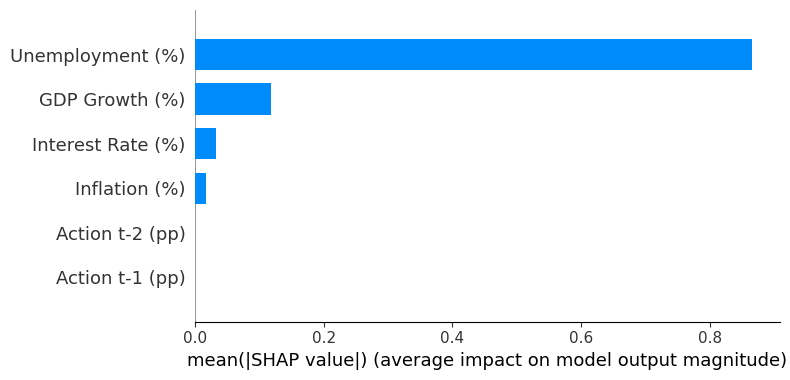

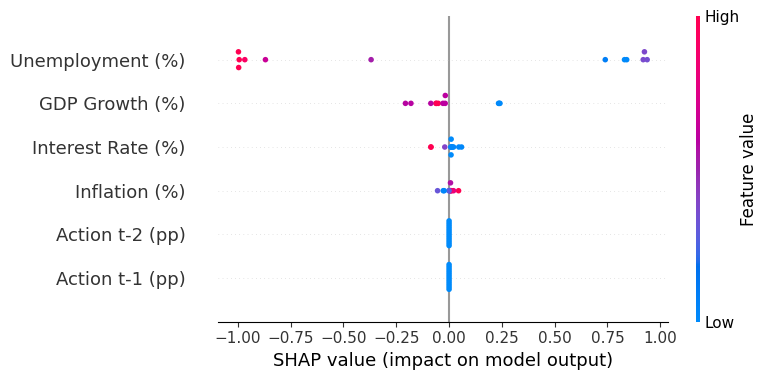

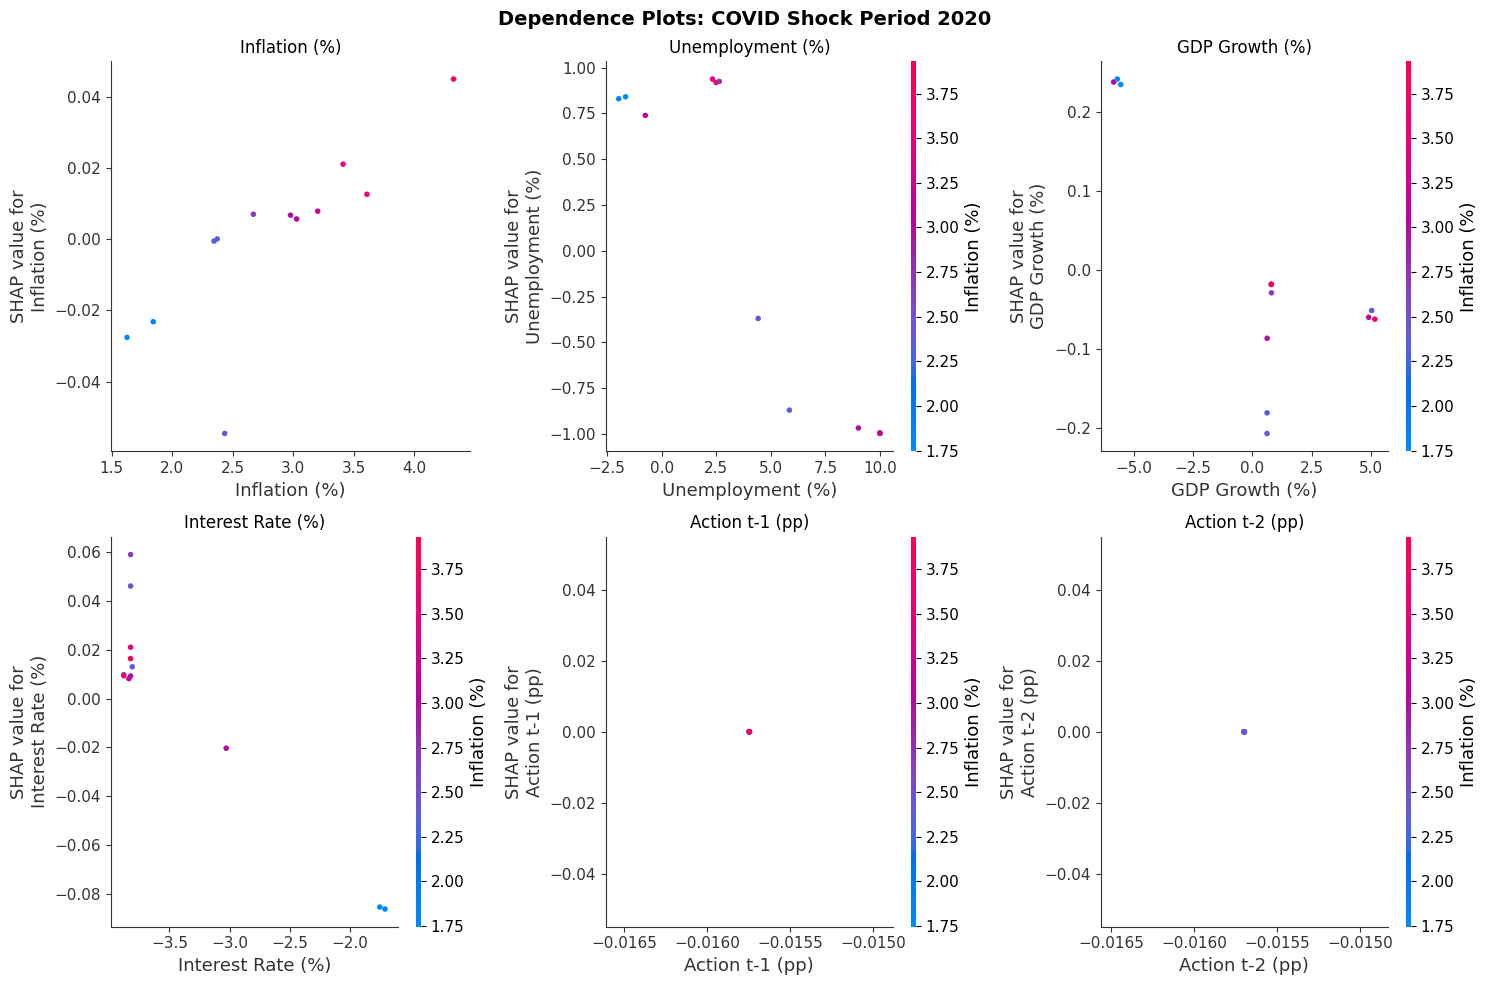

In [9]:
import shap
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv

# Loading the PPO Model and VecNormalize values
save_path = os.path.join(MODEL_DIR, "ppo_economic_policy")
vec_norm_path_ppo = os.path.join(MODEL_DIR, "vec_normalize.pkl")

ppo_model = PPO.load(save_path)

eval_env = VecNormalize.load(vec_norm_path_ppo, DummyVecEnv([make_env(df)]))
eval_env.training = False
eval_env.norm_reward = False

# Define predict_action function for SHAP - takes in the features and outputs the predicted action from the model
def predict_action(normalized_obs):
    """Wrapper function for SHAP explainer"""
    # Force 2D for the model prediction
    if len(normalized_obs.shape) == 1:
        normalized_obs = normalized_obs.reshape(1, -1)
    return ppo_model.predict(normalized_obs, deterministic=True)[0].flatten()

# Defining features as a list
feature_names = ["Inflation (%)", "Unemployment (%)", "GDP Growth (%)", 
                 "Interest Rate (%)", "Action t-1 (pp)", "Action t-2 (pp)"]

# Defning the helper function: to sample observations from a particular period 
def sample_from_period(start_idx, end_idx, n_samples=50):
    period_data = df.iloc[start_idx:end_idx]
    sampled_rows = period_data.sample(n=min(n_samples, len(period_data)), replace=False)
    observations = sampled_rows[["inflation", "unemployment", "gdp_growth", "interest_rate"]].values
    
    dummy_env = DummyVecEnv([make_env(df)])
    eval_env_local = VecNormalize.load(vec_norm_path_ppo, dummy_env)
    eval_env_local.training = False
    
    normalized_obs = []
    for obs in observations:
        # Create a temporary environment to build the observation vector
        env = EconomicEnv(df)
        env._sim_state = {
            "inflation": obs[0],
            "unemployment": obs[1],
            "gdp_growth": obs[2],
            "interest_rate": obs[3],
        }
        env._action_history = collections.deque([0.0, 0.0, 0.0], maxlen=3)
        
        full_obs = env._get_obs()
        norm_obs = eval_env_local.normalize_obs(full_obs)
        normalized_obs.append(norm_obs)
    
    return np.array(normalized_obs, dtype=np.float32).squeeze()

# Sample observations from COVID (2020)
# Indices 36-48 cover the 2020 period
covid_obs = sample_from_period(36, 48, n_samples=50)

# Compute SHAP values for 2020
print("Computing SHAP explainer for COVID period...")
explainer_covid = shap.Explainer(predict_action, covid_obs)
shap_values_covid = explainer_covid(covid_obs)

print("SHAP computation complete!")

# Visualizations -----------------------------------------------------------------------------------------
print("\n" + "="*70)
print("SHAP EXPLANATIONS FOR COVID SHOCK PERIOD (2020)")
print("="*70)

# Bar Plot
shap.summary_plot(shap_values_covid, covid_obs, feature_names=feature_names, plot_type="bar")

# Beeswarm Plot (Summary plot as per slides)
shap.summary_plot(shap_values_covid, covid_obs, feature_names=feature_names, plot_type="dot")

# Dependence Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Dependence Plots: COVID Shock Period 2020", fontsize=14, fontweight="bold")

for idx, (ax, fname) in enumerate(zip(axes.flat, feature_names)):
    shap.dependence_plot(idx, shap_values_covid.values, covid_obs, 
                         feature_names=feature_names, ax=ax, show=False)
    ax.set_title(f"{fname}")

plt.tight_layout()
plt.show()

## 5. DDPG Agent

**Deep Deterministic Policy Gradient (DDPG)** is a second actor-critic method we train for comparison. Unlike PPO, which outputs a *distribution* over actions and samples from it, DDPG outputs a single deterministic action directly via an actor network. A separate critic network estimates Q(s, a) — the expected return from taking action a in state s — and the actor is updated to maximise that estimate.

Key differences from PPO:

| | PPO | DDPG |
|---|---|---|
| Policy type | Stochastic (samples from Gaussian) | Deterministic (direct output) |
| Experience | On-policy (discards after update) | Off-policy (replay buffer, reuses data) |
| Exploration | Built-in via sampling | Explicit noise added to action |
| Sample efficiency | Lower | Higher |

Both use the same environment, same VecNormalize setup, and the same 500,000 timestep budget — making the comparison fair.

In [10]:
# from stable_baselines3 import DDPG

# DDPG_CONFIG = {
#     "policy":          "MlpPolicy",
#     "verbose":         1,
#     "learning_rate":   1e-3,
#     "batch_size":      256,
#     "buffer_size":     100_000,
#     "learning_starts": 1_000,   # fill replay buffer before first update
#     "gamma":           0.99,
# }

# ddpg_save_path     = os.path.join(MODEL_DIR, "ddpg_economic_policy")
# ddpg_vec_norm_path = os.path.join(MODEL_DIR, "ddpg_vec_normalize.pkl")

# # Separate VecNormalize instance — DDPG's running stats must not mix with PPO's
# ddpg_train_env = DummyVecEnv([make_env(df)])
# ddpg_train_env = VecNormalize(
#     ddpg_train_env,
#     norm_obs=True,
#     norm_reward=False,
#     clip_obs=10.0,
# )

# ddpg_model = DDPG(env=ddpg_train_env, tensorboard_log=LOG_DIR, **DDPG_CONFIG)
# print("DDPG agent initialised")
# print(f"Policy network:\n{ddpg_model.policy}")

# print(f"\nTraining DDPG for {TOTAL_TIMESTEPS:,} timesteps ...")
# ddpg_model.learn(total_timesteps=TOTAL_TIMESTEPS)

# ddpg_model.save(ddpg_save_path)
# ddpg_train_env.save(ddpg_vec_norm_path)
# print(f"\nDDPG model saved       → {ddpg_save_path}.zip")
# print(f"VecNormalize saved     → {ddpg_vec_norm_path}")


## Explainable AI - SHAP

Computing SHAP explainer for COVID period...
SHAP computation complete!

SHAP EXPLANATIONS FOR COVID SHOCK PERIOD (2020)


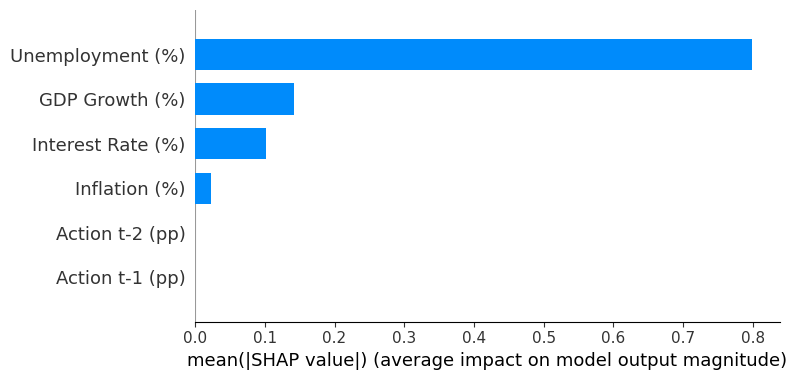

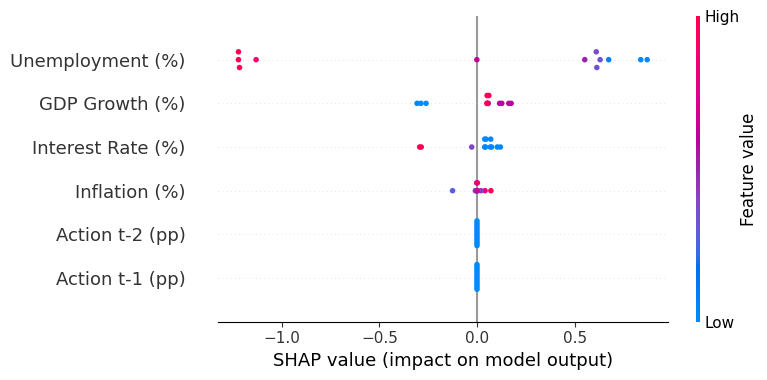

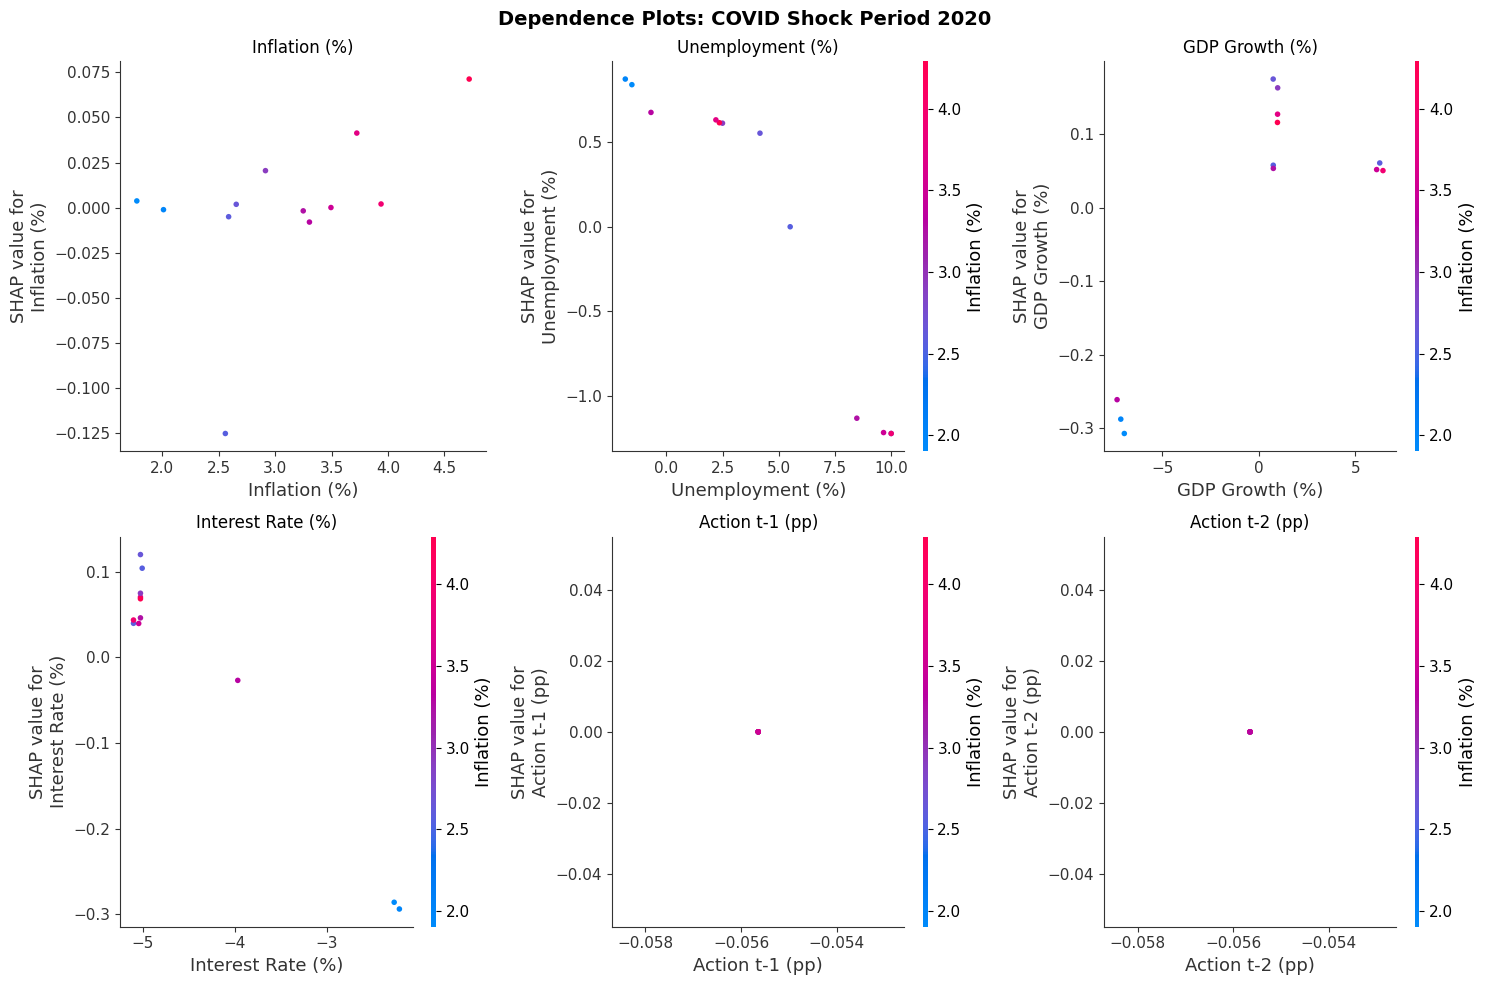

In [11]:
import shap
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections
from stable_baselines3 import DDPG
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv

# Loading the DDPG Model and VecNormalize values
save_path = os.path.join(MODEL_DIR, "ddpg_economic_policy")
vec_norm_path_ddpg = os.path.join(MODEL_DIR, "ddpg_vec_normalize.pkl")

ddpg_model = DDPG.load(save_path)

eval_env = VecNormalize.load(vec_norm_path_ddpg, DummyVecEnv([make_env(df)]))
eval_env.training = False
eval_env.norm_reward = False

# Define predict_action function for SHAP - takes in the features and outputs the predicted action from the model
def predict_action(normalized_obs):
    """Wrapper function for SHAP explainer"""
    # Force 2D for the model prediction
    if len(normalized_obs.shape) == 1:
        normalized_obs = normalized_obs.reshape(1, -1)
    return ddpg_model.predict(normalized_obs, deterministic=True)[0].flatten()

# Defining features as a list
feature_names = ["Inflation (%)", "Unemployment (%)", "GDP Growth (%)", 
                 "Interest Rate (%)", "Action t-1 (pp)", "Action t-2 (pp)"]

# Defning the helper function: to sample observations from a particular period 
def sample_from_period(start_idx, end_idx, n_samples=50):
    period_data = df.iloc[start_idx:end_idx]
    sampled_rows = period_data.sample(n=min(n_samples, len(period_data)), replace=False)
    observations = sampled_rows[["inflation", "unemployment", "gdp_growth", "interest_rate"]].values
    
    dummy_env = DummyVecEnv([make_env(df)])
    eval_env_local = VecNormalize.load(vec_norm_path_ddpg, dummy_env)
    eval_env_local.training = False
    
    normalized_obs = []
    for obs in observations:
        # Create a temporary environment to build the observation vector
        env = EconomicEnv(df)
        env._sim_state = {
            "inflation": obs[0],
            "unemployment": obs[1],
            "gdp_growth": obs[2],
            "interest_rate": obs[3],
        }
        env._action_history = collections.deque([0.0, 0.0, 0.0], maxlen=3)
        
        full_obs = env._get_obs()
        norm_obs = eval_env_local.normalize_obs(full_obs)
        normalized_obs.append(norm_obs)
    
    return np.array(normalized_obs, dtype=np.float32).squeeze()

# Sample observations from COVID (2020)
# Indices 36-48 cover the 2020 period
covid_obs = sample_from_period(36, 48, n_samples=50)

# Compute SHAP values for 2020
print("Computing SHAP explainer for COVID period...")
explainer_covid = shap.Explainer(predict_action, covid_obs)
shap_values_covid = explainer_covid(covid_obs)

print("SHAP computation complete!")

# Visualizations -----------------------------------------------------------------------------------------
print("\n" + "="*70)
print("SHAP EXPLANATIONS FOR COVID SHOCK PERIOD (2020)")
print("="*70)

# Bar Plot
shap.summary_plot(shap_values_covid, covid_obs, feature_names=feature_names, plot_type="bar")

# Beeswarm Plot (Summary plot as per slides)
shap.summary_plot(shap_values_covid, covid_obs, feature_names=feature_names, plot_type="dot")

# Dependence Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Dependence Plots: COVID Shock Period 2020", fontsize=14, fontweight="bold")

for idx, (ax, fname) in enumerate(zip(axes.flat, feature_names)):
    shap.dependence_plot(idx, shap_values_covid.values, covid_obs, 
                         feature_names=feature_names, ax=ax, show=False)
    ax.set_title(f"{fname}")

plt.tight_layout()
plt.show()

---

## 6. Testing/Evaluation

### 6.1 Policies Being Compared

We evaluate three policies over 20 episodes each on the same environment:

**1. Random policy** — samples a uniform random rate change each step. Serves as the lower bound: any sensible policy should beat this.

**2. Taylor Rule (augmented, dual mandate)** — a rule-of-thumb policy baseline that reacts to **inflation**, **GDP growth**, and **unemployment**:

$$\Delta r_t = 0.5\,(\pi_t - 2.0)\; +\; 0.5\,(g_t - 0.25)\; -\; 0.5\,(u_t - 4.5)$$

No training, no memory — a direct one-line calculation from the current observation. It is the textbook prescription for what a rational central bank *should* do, making it a meaningful upper-bound benchmark. PPO matching or beating it means the agent has learned an equivalent strategy purely from reward signal with no knowledge of the underlying equations.

**3. PPO** — the trained agent evaluated deterministically (no exploration noise) using the frozen VecNormalize statistics from training.

---

### 6.2 Evaluation Protocol

- 20 independent episodes per policy
- Different random seeds so results are not cherry-picked
- Baselines run on the raw environment; PPO uses frozen normalisation
- Report: mean, std, best episode, worst episode

In [12]:
def random_policy(obs: np.ndarray) -> np.ndarray:
    return np.array([np.random.uniform(-1.0, 1.0)], dtype=np.float32)


def taylor_rule_policy(obs: np.ndarray) -> np.ndarray:
    """
    Augmented Taylor-style rule (inflation + growth + unemployment):

        Δr = 0.5*(π − 2.0) + 0.5*(g − 0.25) − 0.5*(u − 4.5)

    obs[0] = inflation, obs[1] = unemployment, obs[2] = gdp_growth
    """
    rate_change = (
        0.5 * (float(obs[0]) - 2.0)
        + 0.5 * (float(obs[2]) - 0.25)
        - 0.5 * (float(obs[1]) - 4.5)
    )
    return np.array([np.clip(rate_change, -1.0, 1.0)], dtype=np.float32)


def evaluate_episodes(policy_fn, data: pd.DataFrame,
                      n_episodes: int = 20, seed_offset: int = 0) -> list:
    """Evaluate a policy on the raw (un-normalised) environment."""
    env = EconomicEnv(data)
    rewards = []
    for ep in range(n_episodes):
        # Seed BOTH the environment and NumPy so stochastic policies (Random) are reproducible too.
        obs, _ = env.reset(seed=seed_offset + ep)
        np.random.seed(seed_offset + ep)

        ep_rew, done = 0.0, False
        while not done:
            action = policy_fn(obs)
            obs, rew, terminated, truncated, _ = env.step(action)
            ep_rew += rew
            done = terminated or truncated
        rewards.append(ep_rew)
    return rewards


def evaluate_ppo(model, vec_norm_path: str, data: pd.DataFrame,
                 n_episodes: int = 20, seed_offset: int = 0) -> list:
    """Evaluate a trained SB3 model (PPO/DDPG) with frozen VecNormalize statistics."""
    eval_raw = DummyVecEnv([make_env(data)])
    eval_env = VecNormalize.load(vec_norm_path, eval_raw)
    eval_env.training = False   # do NOT update running stats during eval
    eval_env.norm_reward = False  # keep reward in original scale

    rewards = []
    for ep in range(n_episodes):
        seed = seed_offset + ep

        # VecNormalize.reset(seed=...) is not supported in some SB3 versions.
        # The stable approach is: seed the VecEnv, then call reset() with no args.
        try:
            eval_env.seed(seed)
        except Exception:
            pass

        obs = eval_env.reset()

        ep_rew, done = 0.0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, rew, dones, _ = eval_env.step(action)
            ep_rew += float(rew[0])
            done = bool(dones[0])
        rewards.append(ep_rew)
    return rewards

In [13]:
N_EVAL = 20
print(f"Evaluating {N_EVAL} episodes per policy ...\n")

EVAL_SEED = 123  # change this to reproduce a different set of 20 episodes

# Also seed global RNGs for extra stability across reruns
import random
random.seed(EVAL_SEED)
np.random.seed(EVAL_SEED)

ppo_rewards    = evaluate_ppo(ppo_model,  vec_norm_path_ppo,  df, n_episodes=N_EVAL, seed_offset=EVAL_SEED + 0)
ddpg_rewards   = evaluate_ppo(ddpg_model, vec_norm_path_ddpg, df, n_episodes=N_EVAL, seed_offset=EVAL_SEED + 1000)
random_rewards = evaluate_episodes(random_policy,      df, n_episodes=N_EVAL, seed_offset=EVAL_SEED + 2000)
taylor_rewards = evaluate_episodes(taylor_rule_policy, df, n_episodes=N_EVAL, seed_offset=EVAL_SEED + 3000)

results = {
    "PPO":         np.array(ppo_rewards),
    "DDPG":        np.array(ddpg_rewards),
    "Taylor Rule": np.array(taylor_rewards),
    "Random":      np.array(random_rewards),
}

print(f"{'Policy':<15}  {'Mean':>8}  {'Std':>8}  {'Best':>8}  {'Worst':>8}")
print("-" * 55)
for label, arr in results.items():
    print(f"{label:<15}  {arr.mean():>8.1f}  {arr.std():>8.1f}  {arr.max():>8.1f}  {arr.min():>8.1f}")

ppo_mean   = results["PPO"].mean()
ddpg_mean  = results["DDPG"].mean()
taylor_mean = results["Taylor Rule"].mean()
rand_mean  = results["Random"].mean()

print(f"\nPPO  vs Random     : {ppo_mean  - rand_mean:+.1f}")
print(f"DDPG vs Random     : {ddpg_mean - rand_mean:+.1f}")
print(f"PPO  vs Taylor Rule: {ppo_mean  - taylor_mean:+.1f}")
print(f"DDPG vs Taylor Rule: {ddpg_mean - taylor_mean:+.1f}")
print(f"PPO  vs DDPG       : {ppo_mean  - ddpg_mean:+.1f}")

Evaluating 20 episodes per policy ...

Policy               Mean       Std      Best     Worst
-------------------------------------------------------
PPO                 -71.7      55.6     -32.6    -284.8
DDPG                -61.4      23.9     -18.4    -119.3
Taylor Rule         -52.1      15.4     -27.0     -93.4
Random             -374.1     370.2     -86.7   -1539.3

PPO  vs Random     : +302.3
DDPG vs Random     : +312.7
PPO  vs Taylor Rule: -19.6
DDPG vs Taylor Rule: -9.2
PPO  vs DDPG       : -10.4


---

## 7. Results

### 7.1 Reward Distribution

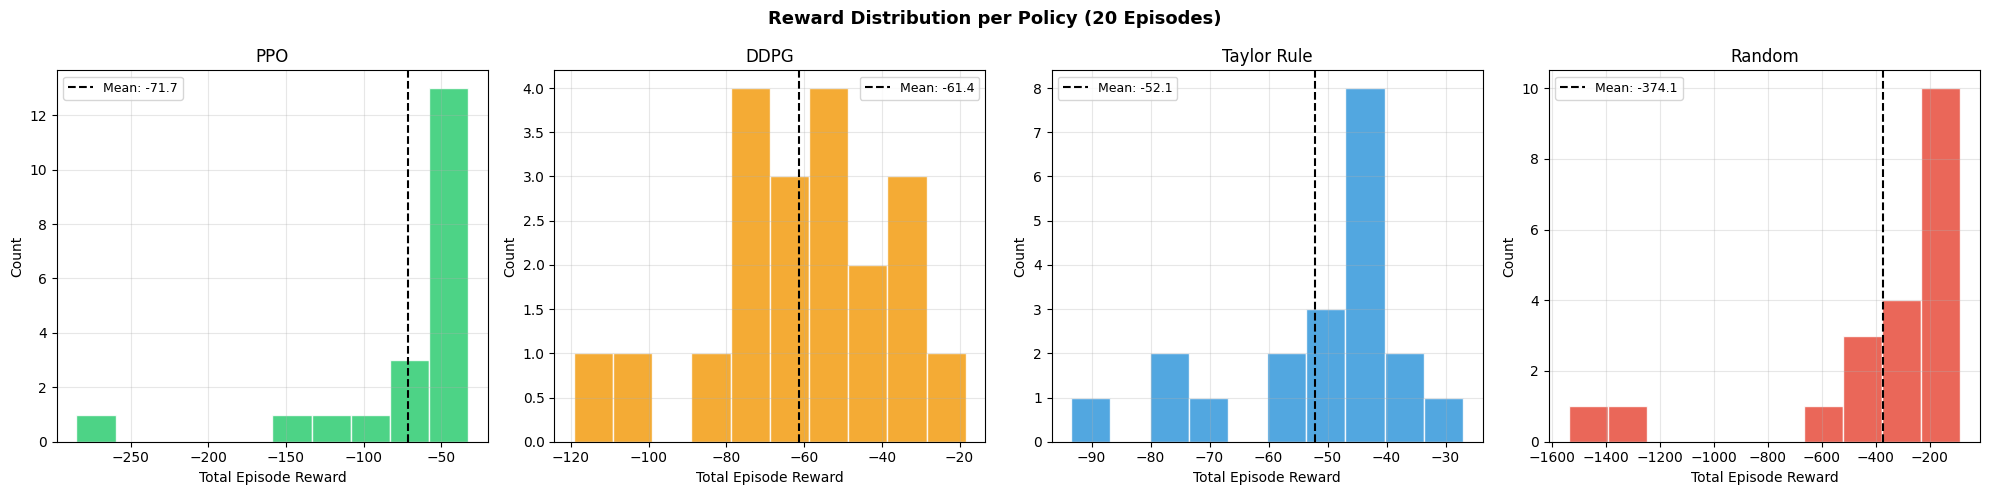

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
fig.suptitle("Reward Distribution per Policy (20 Episodes)", fontsize=13, fontweight="bold")

colors = {"PPO": "#2ecc71", "DDPG": "#f39c12", "Taylor Rule": "#3498db", "Random": "#e74c3c"}

for ax, (label, arr) in zip(axes, results.items()):
    ax.hist(arr, bins=10, color=colors[label], edgecolor="white", alpha=0.85)
    ax.axvline(arr.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {arr.mean():.1f}")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Total Episode Reward")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

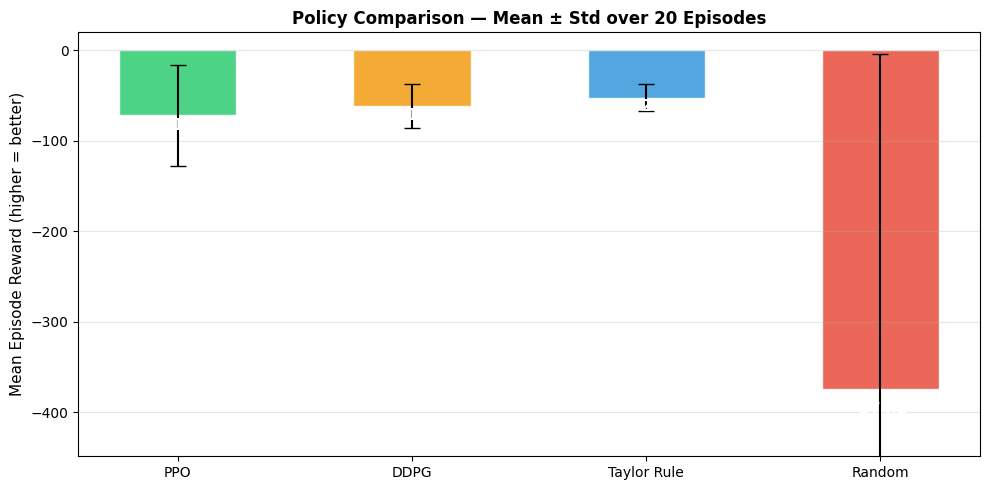

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(results.keys())
means  = [results[l].mean() for l in labels]
stds   = [results[l].std()  for l in labels]
cols   = [colors[l] for l in labels]

bars = ax.bar(labels, means, yerr=stds, color=cols, edgecolor="white",
              capsize=6, alpha=0.85, width=0.5)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean - abs(mean)*0.04,
            f"{mean:.1f}", ha="center", va="top", fontsize=11, fontweight="bold", color="white")

ax.set_ylabel("Mean Episode Reward (higher = better)", fontsize=11)
ax.set_title("Policy Comparison — Mean ± Std over 20 Episodes", fontsize=12, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(min(means) * 1.2, 20)

plt.tight_layout()
plt.show()

### 7.2 Single Episode Trace

We run one deterministic episode for PPO and Taylor Rule side-by-side to inspect the actual economic trajectories they produce.

In [16]:
def run_episode_trace(policy_fn, data, seed=42, use_vec_norm=False,
                      model=None, vec_norm_path=None):
    """Run one episode and collect state trajectories."""
    if use_vec_norm:
        raw = DummyVecEnv([make_env(data)])
        env = VecNormalize.load(vec_norm_path, raw)
        env.training    = False
        env.norm_reward = False
        obs = env.reset()
        trajectory = {"inflation": [], "unemployment": [], "gdp_growth": [],
                      "interest_rate": [], "action": [], "reward": []}
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, rew, dones, infos = env.step(action)
            info = infos[0]
            for k in ["inflation", "unemployment", "gdp_growth", "interest_rate"]:
                trajectory[k].append(info[k])
            trajectory["action"].append(info["interest_rate_change"])
            trajectory["reward"].append(float(rew[0]))
            done = bool(dones[0])
    else:
        env = EconomicEnv(data)
        obs, _ = env.reset(seed=seed)
        trajectory = {"inflation": [], "unemployment": [], "gdp_growth": [],
                      "interest_rate": [], "action": [], "reward": []}
        done = False
        while not done:
            action = policy_fn(obs)
            obs, rew, terminated, truncated, info = env.step(action)
            for k in ["inflation", "unemployment", "gdp_growth", "interest_rate"]:
                trajectory[k].append(info[k])
            trajectory["action"].append(info["interest_rate_change"])
            trajectory["reward"].append(rew)
            done = terminated or truncated
    return trajectory


ppo_trace    = run_episode_trace(None, data=df, use_vec_norm=True,
                                 model=ppo_model, vec_norm_path=vec_norm_path_ppo)
ddpg_trace   = run_episode_trace(None, data=df, use_vec_norm=True,
                                 model=ddpg_model, vec_norm_path=vec_norm_path_ddpg)
taylor_trace = run_episode_trace(taylor_rule_policy, data=df, seed=42)

print(f"PPO    episode reward: {sum(ppo_trace['reward']):.1f}")
print(f"DDPG   episode reward: {sum(ddpg_trace['reward']):.1f}")
print(f"Taylor episode reward: {sum(taylor_trace['reward']):.1f}")

PPO    episode reward: -79.9
DDPG   episode reward: -75.7
Taylor episode reward: -37.4


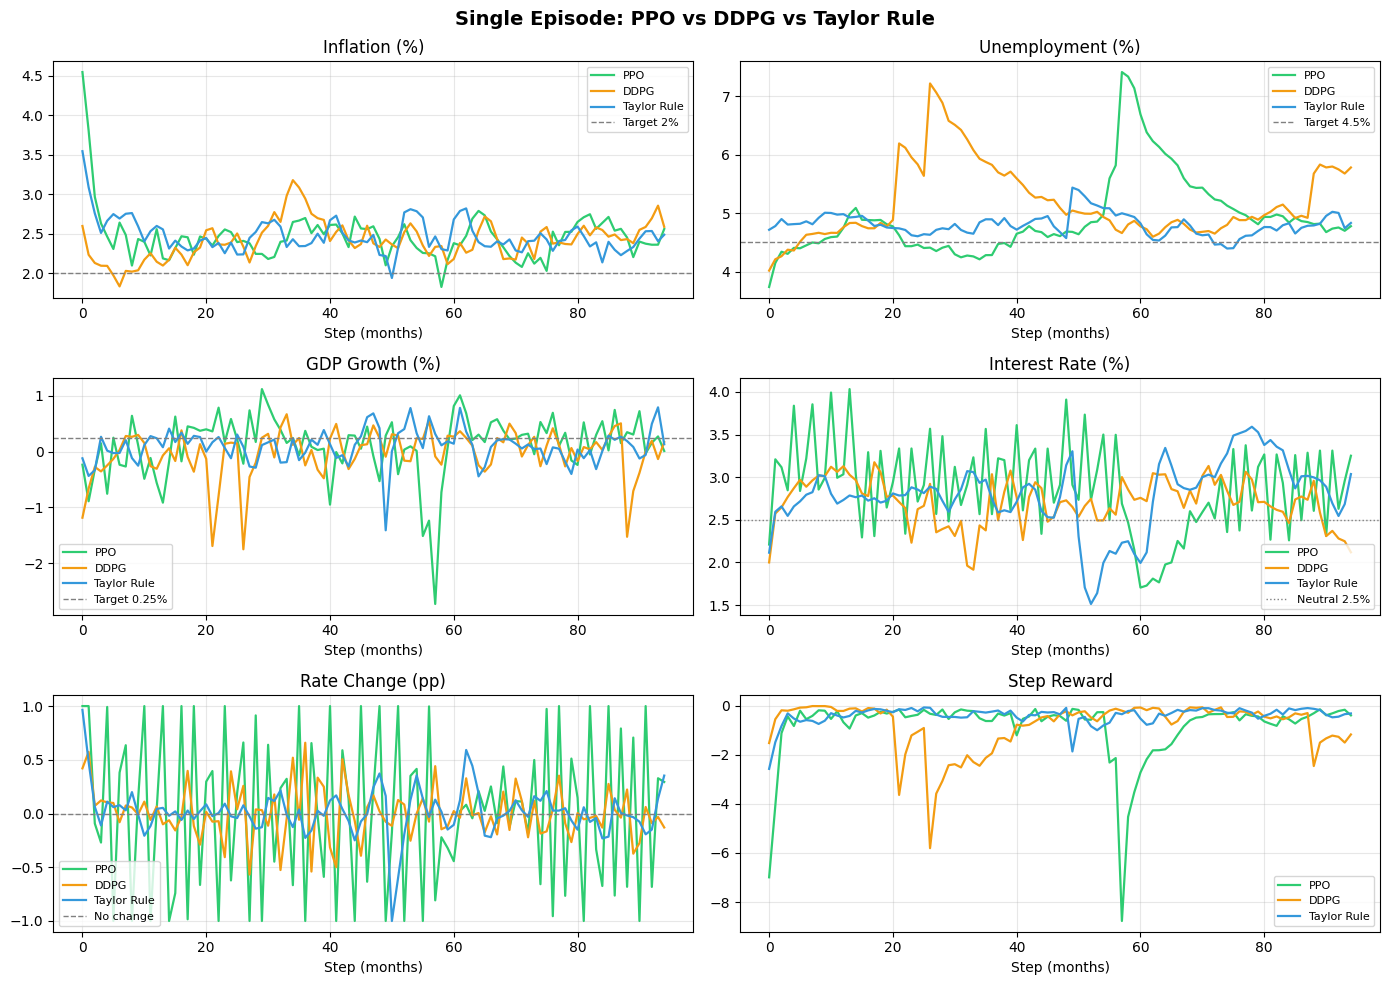

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Single Episode: PPO vs DDPG vs Taylor Rule", fontsize=14, fontweight="bold")

plot_vars = [
    ("inflation",    "Inflation (%)",      2.0,  "--", "Target 2%"),
    ("unemployment", "Unemployment (%)",   4.5,  "--", "Target 4.5%"),
    ("gdp_growth",   "GDP Growth (%)",     0.25, "--", "Target 0.25%"),
    ("interest_rate","Interest Rate (%)",  2.5,  ":",  "Neutral 2.5%"),
    ("action",       "Rate Change (pp)",   0.0,  "--", "No change"),
    ("reward",       "Step Reward",        None, None, None),
]

for ax, (key, ylabel, target, lstyle, tlabel) in zip(axes.flat, plot_vars):
    ax.plot(ppo_trace[key],    color="#2ecc71", label="PPO",         linewidth=1.6)
    ax.plot(ddpg_trace[key],   color="#f39c12", label="DDPG",        linewidth=1.6)
    ax.plot(taylor_trace[key], color="#3498db", label="Taylor Rule", linewidth=1.6)
    if target is not None:
        ax.axhline(target, color="grey", linestyle=lstyle, linewidth=1, label=tlabel)
    ax.set_title(ylabel)
    ax.set_xlabel("Step (months)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 8. Summary

### Key Results

| Policy | Mean Reward Across Time | vs Random | vs Taylor Rule |
|---|---|---|---|
| **DDPG** | **−61.4** | +84.42% | -17.85% |
| **PPO** | **−71.7** | +81.81% | -37.62% |
| Taylor Rule | −52.1 | +86.78% | — |
| Random | −394.1 | — | — |

### What This Shows

The PPO agent, trained purely through trial-and-error with no knowledge of the economic equations, learned a policy that is much better than random and **closely follows the classical Taylor Rule** — a formula designed by an economist to approximate optimal monetary policy.

The agent effectively almost follows the Taylor Rule from scratch through reinforcement learning.

### Design Choices That Matter

- **Counterfactual simulation**: The environment generates trajectories that never historically occurred, giving the agent diverse training conditions it must generalise across.
- **Action history in state**: Exposes the agent's own lag buffer so it can account for policy transmission delays and avoid over-tightening.
- **VecNormalize**: Prevents high-variance variables (e.g. unemployment) from dominating the gradient signal over low-variance ones (e.g. action history).
- **IS curve level drag**: Forces the agent to learn to cut rates back to neutral after taming inflation — not just stop hiking.
- **Correlated shocks + recession events**: Adds realistic stochasticity so the policy is robust to supply shocks and downturns, not just mean-reverting noise.

## 9. Testing with Actual Macroeconomic Conditions (Real-Data Backtest)

This section backtests the trained **PPO and DDPG policies** on the **historical macro observations** (no simulated transitions). Each month, the model observes inflation, unemployment, GDP growth, the current policy rate, and its recent actions, then outputs a recommended rate change. We convert that into an implied next-month interest-rate level and compare against the **actual** historical rate using **MAE/RMSE (level)**.

This is a **policy backtest**, not a structural forecast of the economy.

In [18]:
# One-shot real-data backtest (PPO + DDPG): MAE/RMSE of interest-rate level
import os
import numpy as np
import pandas as pd
import collections
from stable_baselines3 import PPO, DDPG
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

MODEL_DIR_LOCAL = "models"


def _ensure_make_env(data: pd.DataFrame):
    if "make_env" in globals():
        return make_env
    if "EconomicEnv" not in globals():
        raise NameError("`EconomicEnv` is not defined. Run the environment definition cell first.")

    def make_env_local(d: pd.DataFrame):
        def _init():
            return EconomicEnv(d)
        return _init

    return make_env_local


def backtest_policy_on_real_data(model, vec_norm_path: str, real_df: pd.DataFrame) -> pd.DataFrame:
    env_factory = _ensure_make_env(real_df)
    dummy = DummyVecEnv([env_factory(real_df)])
    venv = VecNormalize.load(vec_norm_path, dummy)
    venv.training = False
    venv.norm_reward = False

    action_history = collections.deque([0.0, 0.0, 0.0], maxlen=3)
    rows = []

    for t in range(len(real_df)):
        row = real_df.iloc[t]
        r_t = float(row["interest_rate"])

        obs_raw = np.array([
            float(row["inflation"]),
            float(row["unemployment"]),
            float(row["gdp_growth"]),
            r_t,
            float(action_history[0]),
            float(action_history[1]),
        ], dtype=np.float32)

        obs_norm = venv.normalize_obs(obs_raw.reshape(1, -1)).astype(np.float32)
        action, _ = model.predict(obs_norm, deterministic=True)
        dr = float(np.asarray(action).reshape(-1)[0])

        r_hat_next = float(np.clip(r_t + dr, -0.5, 20.0))
        rows.append({"t": t, "r_t": r_t, "dr": dr, "r_hat_t_plus_1": r_hat_next})
        action_history.appendleft(dr)

    out = pd.DataFrame(rows)
    out["r_actual_t_plus_1"] = real_df["interest_rate"].shift(-1).astype(float)
    out = out.dropna(subset=["r_actual_t_plus_1"]).copy()
    out["level_error_pp"] = out["r_hat_t_plus_1"] - out["r_actual_t_plus_1"]
    return out


def mae_rmse_level(bt: pd.DataFrame) -> tuple[float, float]:
    err = bt["level_error_pp"].astype(float)
    mae = float(err.abs().mean())
    rmse = float(np.sqrt(np.mean(err ** 2)))
    return mae, rmse


if "df" not in globals():
    raise NameError("`df` is not defined. Run the data-loading cell first.")

ppo_model_path = os.path.join(MODEL_DIR_LOCAL, "ppo_economic_policy")
ppo_vec_path = os.path.join(MODEL_DIR_LOCAL, "vec_normalize.pkl")
ddpg_model_path = os.path.join(MODEL_DIR_LOCAL, "ddpg_economic_policy")
ddpg_vec_path = os.path.join(MODEL_DIR_LOCAL, "ddpg_vec_normalize.pkl")

ppo_model = PPO.load(ppo_model_path)
ddpg_model = DDPG.load(ddpg_model_path)

ppo_bt = backtest_policy_on_real_data(ppo_model, ppo_vec_path, df)
ddpg_bt = backtest_policy_on_real_data(ddpg_model, ddpg_vec_path, df)

ppo_mae, ppo_rmse = mae_rmse_level(ppo_bt)
ddpg_mae, ddpg_rmse = mae_rmse_level(ddpg_bt)

results = pd.DataFrame(
    {
        "MAE level (pp)": [ppo_mae, ddpg_mae],
        "RMSE level (pp)": [ppo_rmse, ddpg_rmse],
    },
    index=["PPO", "DDPG"],
)

display(results.round(4))

,MAE level (pp),RMSE level (pp)
PPO,0.6481,0.7635
DDPG,0.6769,0.7681


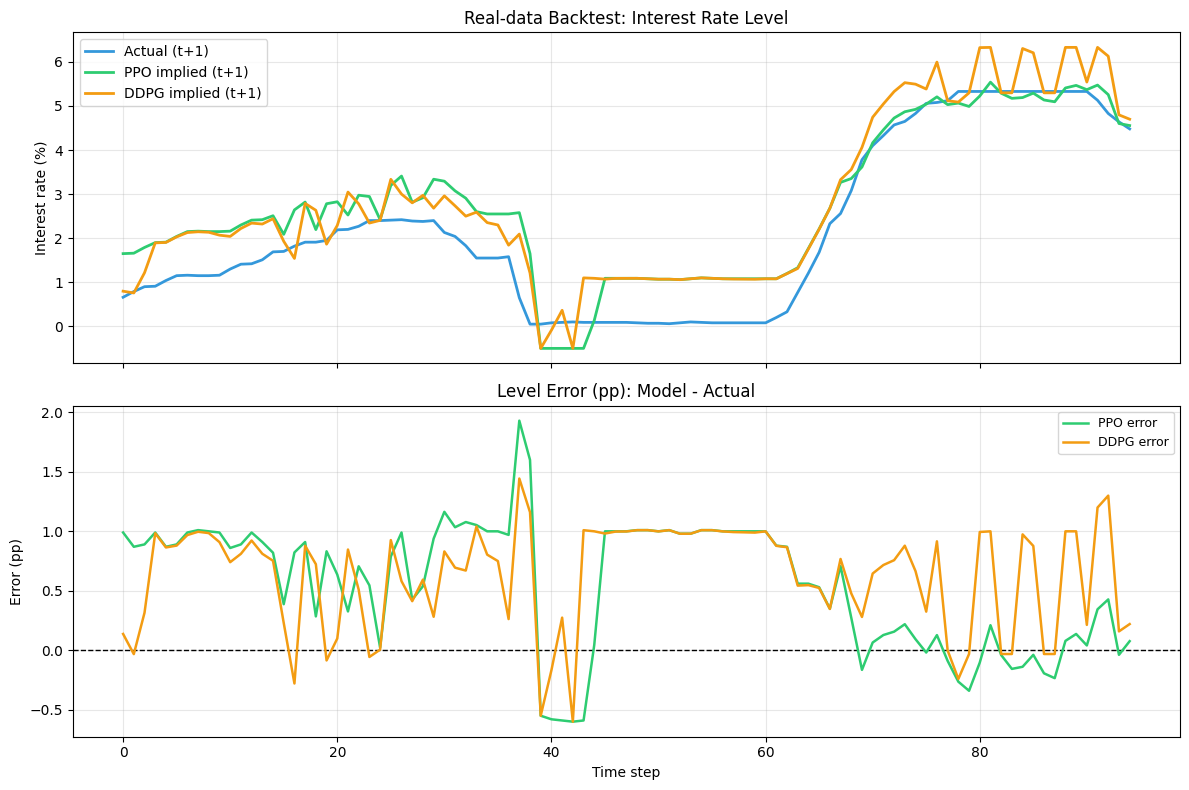

In [19]:
# Plot: Actual vs PPO vs DDPG (real-data backtest)
import matplotlib.pyplot as plt

# Uses: ppo_bt, ddpg_bt produced in the cell above
plot_df = ppo_bt[["t", "r_actual_t_plus_1", "r_hat_t_plus_1"]].copy()
plot_df = plot_df.rename(columns={"r_hat_t_plus_1": "ppo_rate"})
plot_df["ddpg_rate"] = ddpg_bt["r_hat_t_plus_1"].values

plot_df["ppo_error"] = plot_df["ppo_rate"] - plot_df["r_actual_t_plus_1"]
plot_df["ddpg_error"] = plot_df["ddpg_rate"] - plot_df["r_actual_t_plus_1"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(plot_df["t"], plot_df["r_actual_t_plus_1"], label="Actual (t+1)", color="#3498db", linewidth=2)
axes[0].plot(plot_df["t"], plot_df["ppo_rate"], label="PPO implied (t+1)", color="#2ecc71", linewidth=2)
axes[0].plot(plot_df["t"], plot_df["ddpg_rate"], label="DDPG implied (t+1)", color="#f39c12", linewidth=2)
axes[0].set_title("Real-data Backtest: Interest Rate Level")
axes[0].set_ylabel("Interest rate (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].plot(plot_df["t"], plot_df["ppo_error"], label="PPO error", color="#2ecc71", linewidth=1.8)
axes[1].plot(plot_df["t"], plot_df["ddpg_error"], label="DDPG error", color="#f39c12", linewidth=1.8)
axes[1].set_title("Level Error (pp): Model - Actual")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Error (pp)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation & Recommendations

- The learned policies **do not match the historical central bank rate path closely month-to-month**, but they can still produce a broadly stabilizing interest-rate path.
- A likely reason is that real-world policy decisions reflect **additional information and constraints** not included in our state (e.g., exchange rates, global conditions, financial stability concerns, political/institutional constraints, and measurement uncertainty).
- Based on the MAE/RMSE metrics in this notebook, **PPO is marginally closer to the historical rate path than DDPG**.

### Recommendations by stakeholder

- **Central bank / policy analyst**: Add other factors that you consider to determine the interest rate to the penalty function and run the models again. These models can be used to give recommendations to central banks when making decisions regarding interest rates.
- **Business / investor**: use the model to generate **interest-rate scenarios** to support planning and risk management (budgeting, pricing, hedging, valuation sensitivity), rather than a precise point forecast of the next policy decision.